### Importing

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "House_prices.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
with open("data_description.txt", "r") as file:
    print(file.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

### EDA

In [198]:
df.shape

(1460, 81)

In [199]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [200]:
df.duplicated().sum()

np.int64(0)

In [201]:
df.isnull().sum().sort_values(ascending = False).head(20).to_frame("Missing")

,Missing
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [202]:
df["PoolQC"] = df["PoolQC"].fillna("No Pool")
df["MiscFeature"] = df["MiscFeature"].fillna("None")
df["Alley"] = df["Alley"].fillna("No alley access")
df["Fence"] = df["Fence"].fillna("No Fence")
df["MasVnrType"] = df["MasVnrType"].fillna(df["MasVnrType"].mode()[0])
df["FireplaceQu"] = df["FireplaceQu"].fillna("No Fireplace")
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["GarageQual"] = df["GarageQual"].fillna("No Garage")
df["GarageFinish"] = df["GarageFinish"].fillna("No Garage")
df["GarageType"] = df["GarageType"].fillna("No Garage")
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)
df["GarageCond"] = df["GarageCond"].fillna("No Garage")
df["BsmtFinType2"] = df["BsmtFinType2"].fillna("No Basement")
df["BsmtExposure"] = df["BsmtExposure"].fillna("No Basement")
df["BsmtCond"] = df["BsmtCond"].fillna("No Basement")
df["BsmtQual"] = df["BsmtQual"].fillna("No Basement")
df["BsmtFinType1"] = df["BsmtFinType1"].fillna("No Basement")
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [203]:
df.info(verbose = False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 81 entries, Id to SalePrice
dtypes: float64(3), int64(35), object(43)
memory usage: 924.0+ KB


In [204]:
df.describe(include = ["object"]).T.sort_values(by = "unique" , ascending = False)

,count,unique,top,freq
Neighborhood,1460,25,NAmes,225
Exterior2nd,1460,16,VinylSd,504
Exterior1st,1460,15,VinylSd,515
SaleType,1460,9,WD,1267
Condition1,1460,9,Norm,1260
RoofMatl,1460,8,CompShg,1434
Condition2,1460,8,Norm,1445
HouseStyle,1460,8,1Story,726
BsmtFinType2,1460,7,Unf,1256
Functional,1460,7,Typ,1360


In [205]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1460.0,69.863699,22.027677,21.0,60.00,69.0,79.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1460.0,103.117123,180.731373,0.0,0.00,0.0,164.25,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [206]:
df.describe()["SalePrice"]

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

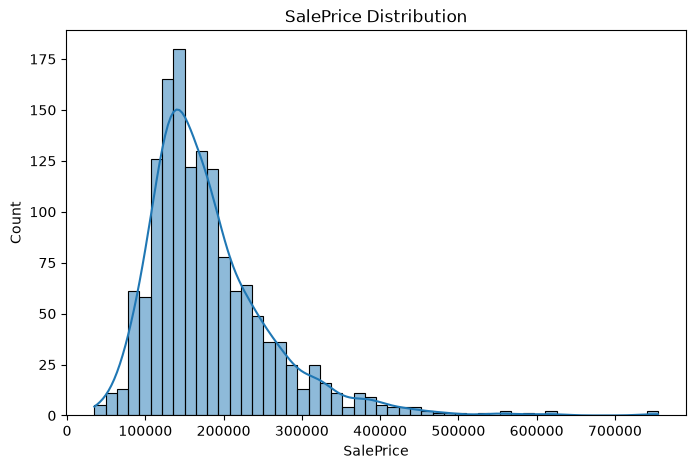

In [207]:
plt.figure(figsize = (8 , 5))
sns.histplot(df["SalePrice"] , bins = 50 , kde = True)

plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

In [208]:
df.corr(numeric_only = True)["SalePrice"].sort_values(ascending = False).drop("SalePrice").head(6)

OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
1stFlrSF       0.605852
Name: SalePrice, dtype: float64

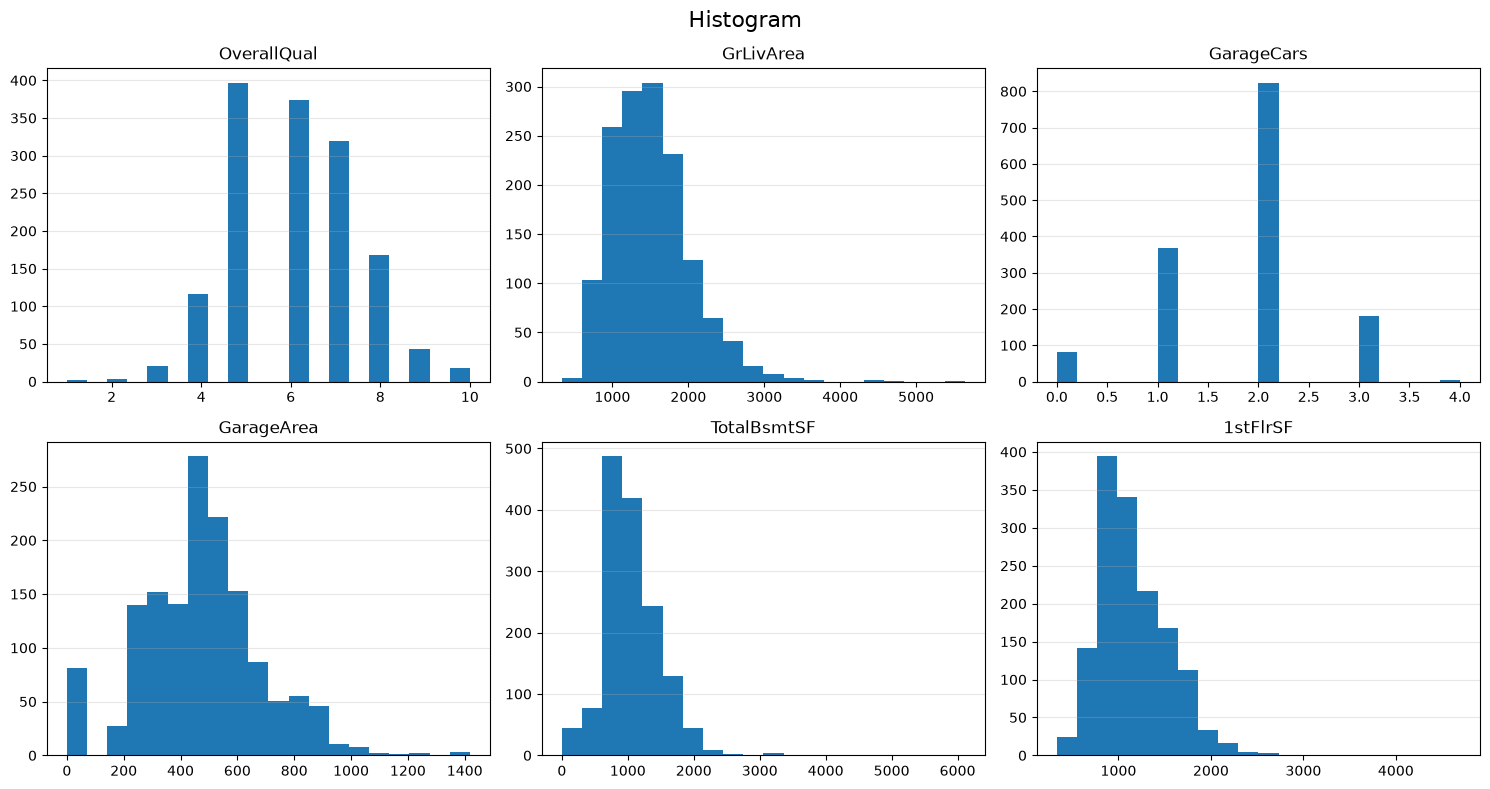

In [209]:
features = ["OverallQual" , "GrLivArea" , "GarageCars" , "GarageArea" , "TotalBsmtSF" , "1stFlrSF"]

fig , axes = plt.subplots(nrows = 2 , ncols = 3 , figsize = (15 , 8))

for ax , feature in zip(axes.flat , features):
    ax.hist(df[feature] , bins = 20)
    ax.set_title(feature)
    ax.grid(axis = "y" , alpha = 0.3)

plt.suptitle("Histogram" , fontsize = 16)
plt.tight_layout()
plt.show()

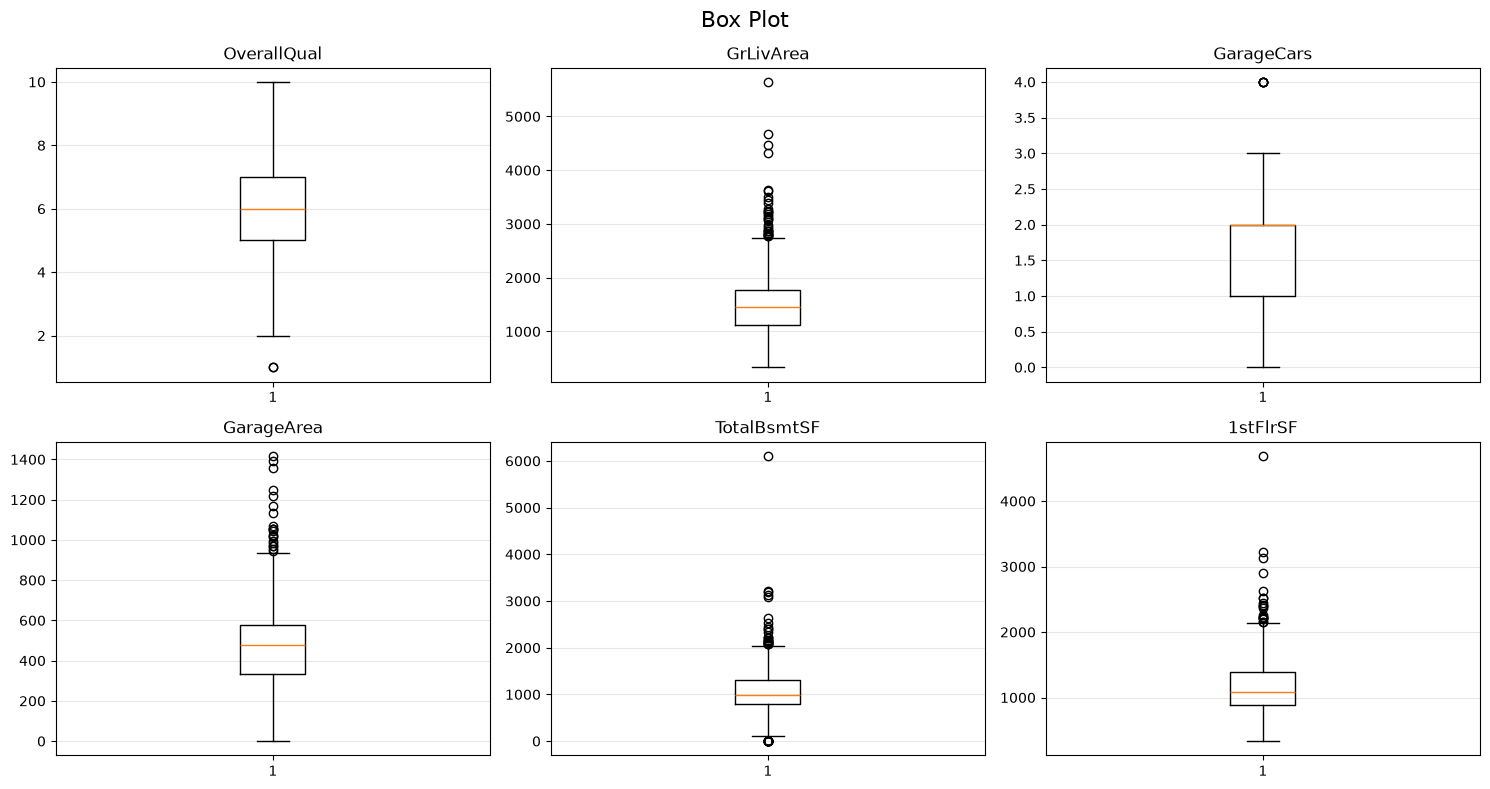

In [210]:
features = ["OverallQual" , "GrLivArea" , "GarageCars" , "GarageArea" , "TotalBsmtSF" , "1stFlrSF"]

fig , axes = plt.subplots(nrows = 2 , ncols = 3 , figsize = (15 , 8))

for ax , feature in zip(axes.flat , features):
    ax.boxplot(df[feature])
    ax.set_title(feature)
    ax.grid(axis = "y" , alpha = 0.3)

plt.suptitle("Box Plot" , fontsize = 16)
plt.tight_layout()
plt.show()

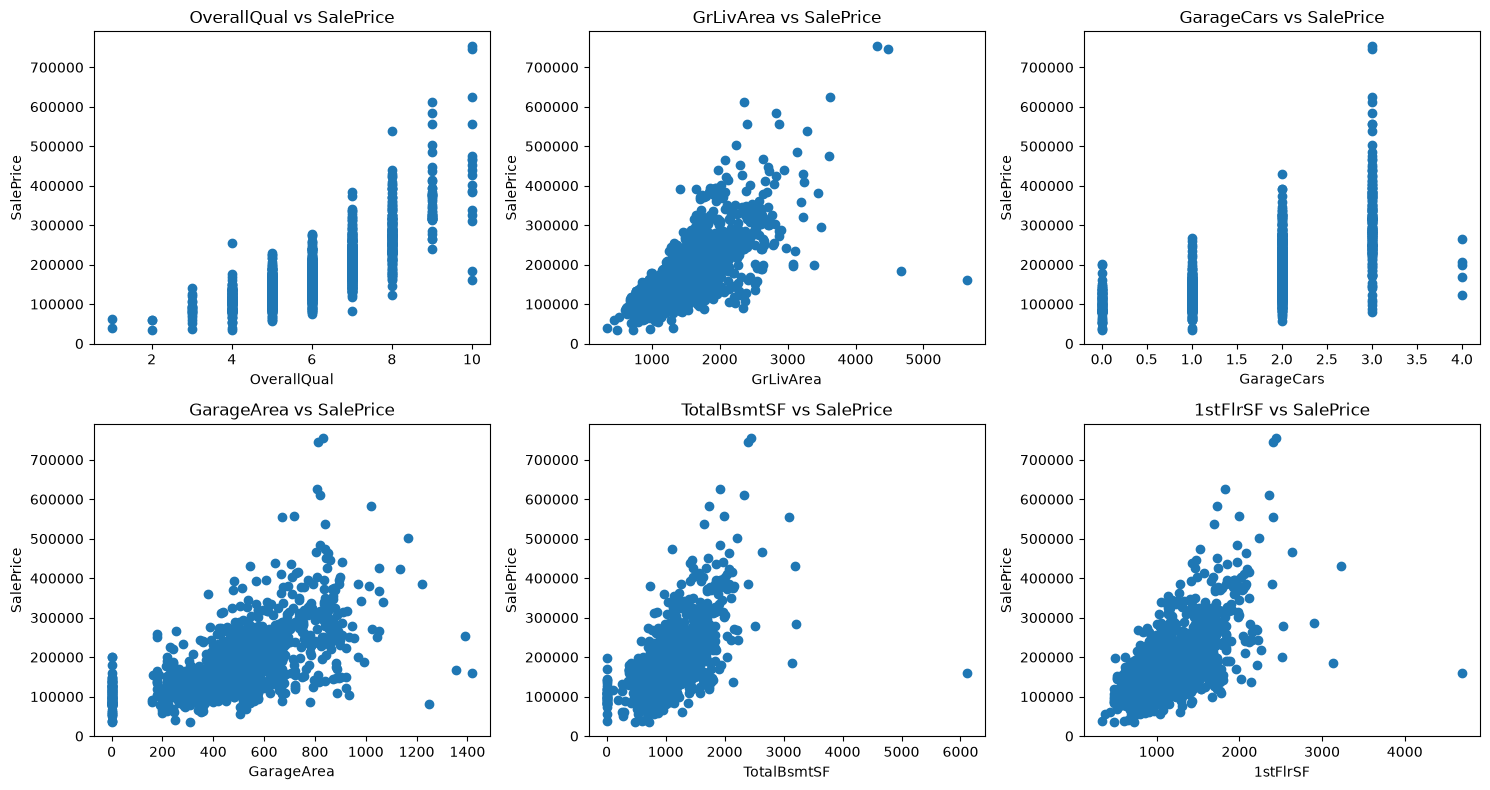

In [211]:
fig , axes = plt.subplots(nrows = 2 , ncols = 3 , figsize = (15 , 8))

features = ["OverallQual" , "GrLivArea" , "GarageCars" , "GarageArea" , "TotalBsmtSF" , "1stFlrSF"]

for ax , feature in zip(axes.flat , features):
    ax.scatter(df[feature] , df["SalePrice"])
    ax.set_xlabel(feature)
    ax.set_ylabel("SalePrice")
    ax.set_title(f"{feature} vs SalePrice")

plt.tight_layout()
plt.show()

In [212]:
df = df.drop(index = df[(df["OverallQual"] > 9) & (df["SalePrice"] < 200000)].index)
df = df.drop(index = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)].index)
df = df.drop(index = df[(df["GarageArea"] > 1200) & (df["SalePrice"] < 300000)].index)
df = df.drop(index = df[(df["TotalBsmtSF"] > 5000) & (df["SalePrice"] < 300000)].index)
df = df.drop(index = df[(df["1stFlrSF"] > 4000) & (df["SalePrice"] < 300000)].index)

### Feature & Target Split

In [213]:
X = df.drop(columns = ["SalePrice"])
y = df["SalePrice"]

### Train & Test Split

In [214]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.21 , random_state = 101)

### Model Training

In [215]:
cat_cols = X.select_dtypes(include = ["object"]).columns.tolist()

In [216]:
model = CatBoostRegressor(loss_function = "RMSE" , iterations = 500 , 
                          learning_rate = 0.05 , depth = 6 , 
                          verbose = 100 , random_seed = 101)
model.fit(X_train , y_train , cat_features = cat_cols)

0:	learn: 78423.3099156	total: 191ms	remaining: 1m 35s
100:	learn: 20238.5078813	total: 7.28s	remaining: 28.8s
200:	learn: 16094.7077875	total: 14.2s	remaining: 21.2s
300:	learn: 14332.6290091	total: 23s	remaining: 15.2s
400:	learn: 12598.9672851	total: 32.5s	remaining: 8.01s
499:	learn: 11256.6814984	total: 41.6s	remaining: 0us


CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=101, verbose=100)

### Prediction

In [217]:
y_pred = model.predict(X_test)

### Evaluation

In [218]:
print("Final Model : Cat Boost Regressor")
print(f"MAE : {mean_absolute_error(y_test , y_pred)}")
print(f"MSE : {mean_squared_error(y_test , y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test , y_pred)}")
print(f"R2 Score : {r2_score(y_test , y_pred)}")

Final Model : Cat Boost Regressor
MAE : 14627.868800784605
MSE : 471927099.5732425
RMSE : 21723.883160550336
R2 Score : 0.9120330876974941


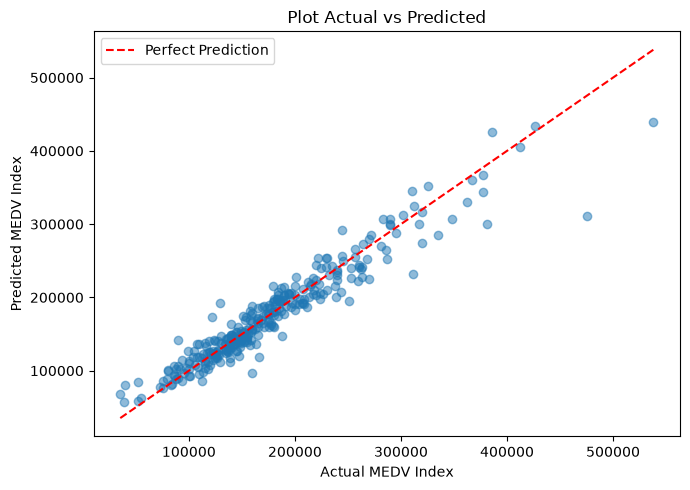

In [219]:
plt.figure(figsize = (7 , 5))
plt.scatter(y_test , y_pred , alpha = 0.5)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , color = "red" , linestyle = "--" , label = "Perfect Prediction")

plt.title("Plot Actual vs Predicted")
plt.xlabel("Actual MEDV Index")
plt.ylabel("Predicted MEDV Index")
plt.tight_layout()
plt.legend()
plt.show()

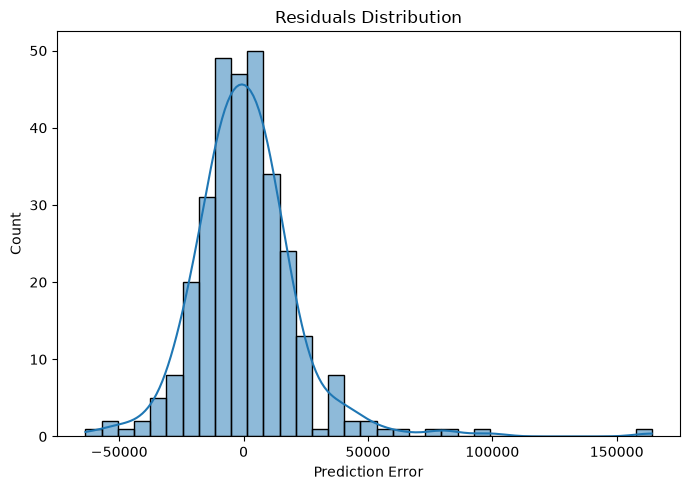

In [220]:
residuals = y_test - y_pred

plt.figure(figsize = (7 , 5))
sns.histplot(residuals , kde = True)

plt.title("Residuals Distribution")
plt.xlabel("Prediction Error")
plt.tight_layout()
plt.show()